<h2>Banking Hypothesis Testing</h2>

In [28]:
# importing Libraries
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt


from scipy.stats import spearmanr, kruskal



In [29]:
# Importing data
df=pd.read_csv('../Data/banking_after_EDA.csv')
df.head()

,Client_Id,Name,Age,Location_Id,Joined_Bank,Banking_Contact,Nationality,Occupation,Fee_Structure,Loyalty_Classification,...,GenderId,IAID,Age_Group,Tenure_Years,Join_Year,Total_Assets,Total_Liabilities,Debt_to_Income,Account_Diversity,Net_Worth
0,IND81288,Raymond Mills,24,34324,2019-05-06,Anthony Torres,American,Safety Technician IV,High,Jade,...,1,1,Under 30,7.1,2019,2003506.59,1911202.76,25.352638,1223201.30,92303.83
1,IND65833,Julia Spencer,23,42205,2001-12-10,Jonathan Hawkins,African,Software Consultant,High,Jade,...,1,2,Under 30,24.5,2001,1158881.71,3273398.41,11.294034,635319.84,-2114516.70
2,IND47499,Stephen Murray,27,7314,2010-01-25,Anthony Berry,European,Help Desk Operator,High,Gold,...,2,3,Under 30,16.4,2010,1576227.49,1605422.16,9.447259,934802.82,-29194.67
3,IND72498,Virginia Garza,40,34594,2019-03-28,Steve Diaz,American,Geologist II,Mid,Silver,...,1,4,30-45,7.2,2019,1053630.64,1273802.35,3.569993,1340358.16,-220171.71
4,IND60181,Melissa Sanders,46,41269,2012-07-20,Shawn Long,American,Assistant Professor,Mid,Platinum,...,2,5,45-60,13.9,2012,535860.13,2726493.56,20.858836,605008.84,-2190633.43


<h4>Hypothesis-1: Does Estimated Income influence Total Assets?</h4> 
<h6>Business Qs:</h6> Do wealthier customer maintain more assets with bank? 

<b>Null Hypothesis (H₀)</b> There is no relationship between income and total assets </br>
<b>Alternate Hypotheis (H₁)</b> There is a relationship between income and total assets

<h5>Test: Spearman Correlation</h5>

In [30]:
corr, p = spearmanr(
    df['Estimated_Income'],
    df['Total_Assets']
)

print(f'Spearman Correlation: {corr:.3f}')
print(f"P-value: {p} ~ {p:.5f}")

if p < 0.05:
    print("Reject H₀")
else:
    print('Fail to Reject H₀')

Spearman Correlation: 0.191
P-value: 4.3011812217475006e-26 ~ 0.00000
Reject H₀


💾Saved


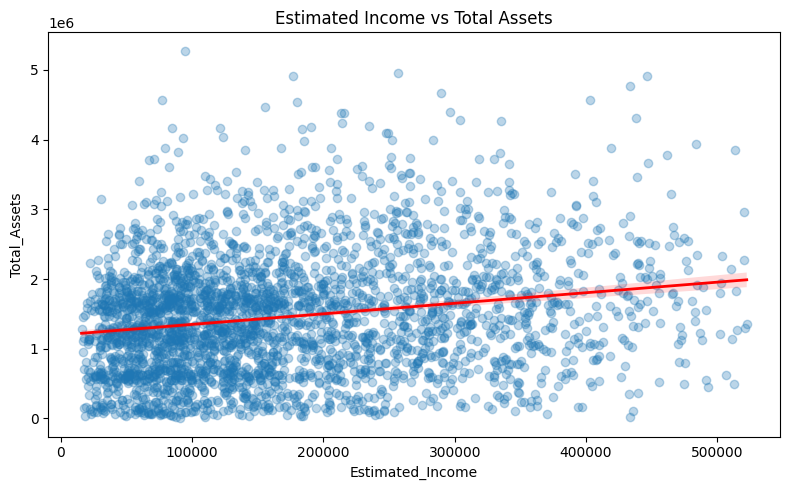

In [31]:
# Visualization
plt.figure(figsize=(8,5))
sns.regplot(
    x='Estimated_Income',
    y='Total_Assets',
    data=df,
    scatter_kws={'alpha':0.3},
    line_kws={'color':'red', 'linewidth':2}
)
plt.title('Estimated Income vs Total Assets')
plt.tight_layout()
plt.savefig('../reports/Results_hypothesis_testing/01_Estimated_Income_vs_Total_Assets.png',bbox_inches='tight')
print('💾Saved')


<h4>Hypothesis-2: Does Estimated Income influence Net Worth?</h4> 
<h6>Business Qs:</h6> Do higher-income customer possess greater net worth? 

<b>Null Hypothesis (H₀)</b> There is no relationship between income and net worth </br>
<b>Alternate Hypotheis (H₁)</b> There is a relationship between income and net worth

<h5>Test: Spearman Correlation</h5>

In [32]:
corr, p = spearmanr(
    df['Estimated_Income'],
    df['Net_Worth']
)

print(f'Spearman Correlation: {corr:.3f}')
print(f'P-value: {p} ~ {p:.5f}')

if p < 0.05:
    print("Reject H₀")
else:
    print('Fail to Reject H₀')

Spearman Correlation: -0.191
P-value: 4.408824602895439e-26 ~ 0.00000
Reject H₀


💾Saved


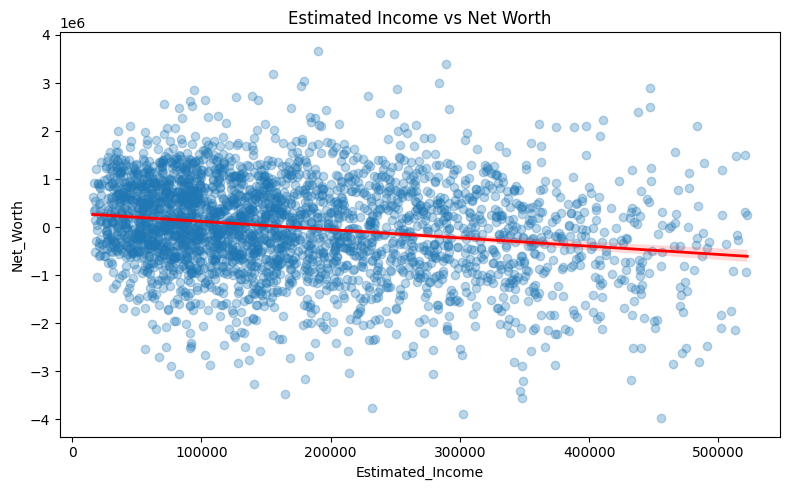

In [33]:
# Visulaiztion
plt.figure(figsize=(8,5))
sns.regplot(
    x='Estimated_Income',
    y='Net_Worth',
    data=df,
    scatter_kws={'alpha':0.3},
    line_kws={'color':'red', 'linewidth':2}
)
plt.title('Estimated Income vs Net Worth')
plt.tight_layout()
plt.savefig('../reports/Results_hypothesis_testing/02_Estimated_Income_vs_Net_Worth.png',bbox_inches='tight')
print('💾Saved')


<h4>Hypothesis-3: Does Debt-to-Income influence Risk Weighting?</h4> 
<h6>Business Qs:</h6> Does customer debt increases financial risk? 

<b>Null Hypothesis (H₀)</b> Debt-to-Income ratio is not associated with Risk Weighting. </br>
<b>Alternate Hypotheis (H₁)</b> Debt-to-Income ratio is associated with Right Weighting.

<h5>Test: Spearman Correlation</h5>

In [34]:
corr, p = spearmanr(
    df['Debt_to_Income'],
    df['Risk_Weighting']
)

print(f"Spearman Correlation: {corr:.3f}")
print(f"P-value: {p} ~ {p:.5f}")

if p < 0.05:
    print("Reject H₀")
else:
    print('Fail to Reject H₀')

Spearman Correlation: -0.175
P-value: 4.217381352934517e-22 ~ 0.00000
Reject H₀


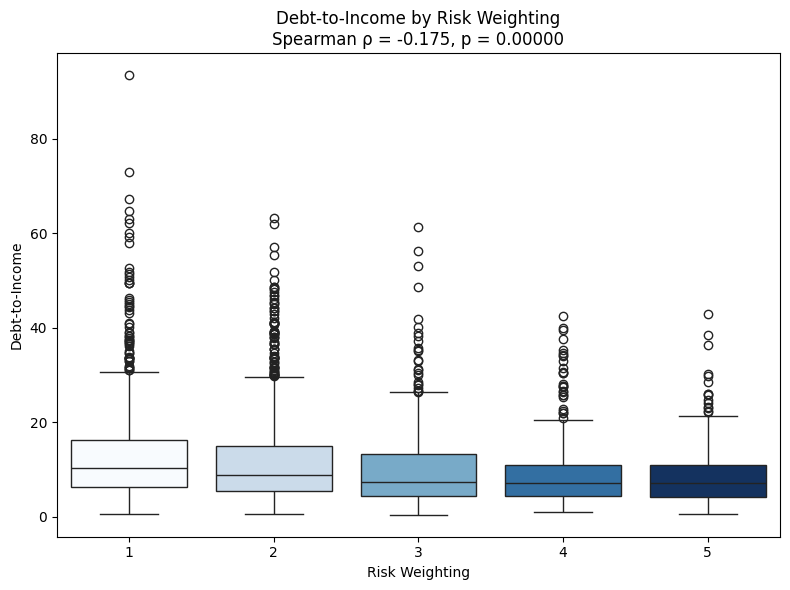

💾Saved


In [35]:
# Visualization
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x='Risk_Weighting',
    y='Debt_to_Income',
    hue='Risk_Weighting',      # avoids FutureWarning
    palette='Blues',
    legend=False
)

plt.title(
    f'Debt-to-Income by Risk Weighting\n'
    f'Spearman ρ = {corr:.3f}, p = {p:.5f}',
    fontsize=12
)

plt.xlabel('Risk Weighting')
plt.ylabel('Debt-to-Income')

plt.tight_layout()

plt.savefig('../reports/Results_hypothesis_testing/03_risk_weighting_boxplot.png', bbox_inches='tight')

plt.show()

print('💾Saved')

<h4>Hypothesis-4: Does Customer Tenure influence Total Assets?</h4> 
<h6>Business Qs:</h6> Do long-term customers maintain larger asset portfolios? 

<b>Null Hypothesis (H₀)</b> Customer tenure is not associated with Total Assets. </br>
<b>Alternate Hypotheis (H₁)</b> Customer tenure is associated with Total Assets.

<h5>Test: Spearman Correlation</h5>

In [36]:
corr, p = spearmanr(
    df['Tenure_Years'],
    df['Total_Assets']
)

print(f"Spearman Correlation: {corr:.3f}")
print(f"P-value: {p} ~ {p:.5f}")

if p < 0.05:
    print("Reject H₀")
else:
    print("Fail to reject H₀")

Spearman Correlation: -0.006
P-value: 0.7543016145170699 ~ 0.75430
Fail to reject H₀


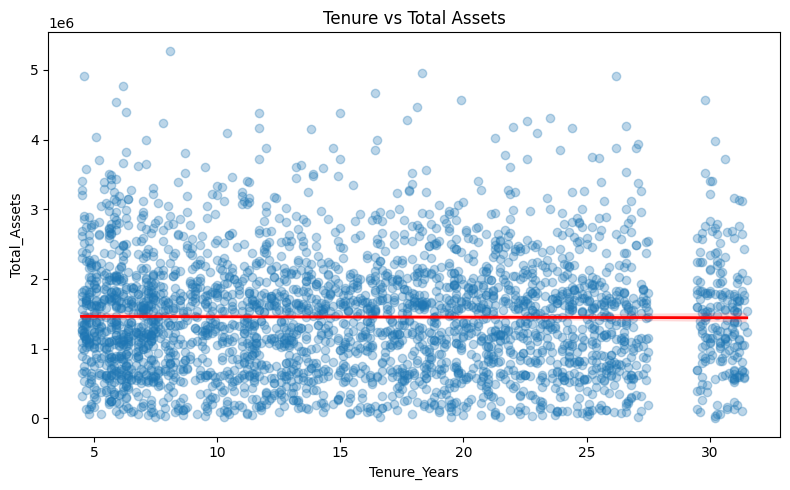

💾Saved


In [37]:
# Visualization
plt.figure(figsize=(8,5))
sns.regplot(
    x='Tenure_Years',
    y='Total_Assets',
    data=df,
    scatter_kws={'alpha':0.3},
    line_kws={'color':'red', 'linewidth':2}
)
plt.title('Tenure vs Total Assets')
plt.tight_layout()
plt.savefig('../reports/Results_hypothesis_testing/04_risk_weighting_boxplot.png', bbox_inches='tight')
plt.show()
print('💾Saved')


<h4>Hypothesis-5: Does Account Diversity influence Net Worth?</h4> 
<h6>Business Qs:</h6> Do customers with more banking products have higher net worth? 

<b>Null Hypothesis (H₀)</b> Account Diversity and Net Worth are unrelated. </br>
<b>Alternate Hypotheis (H₁)</b> Account Diversity and Net Worth are related.

<h5>Test: Spearman Correlation</h5>

In [38]:
corr, p = spearmanr(
    df['Account_Diversity'],
    df['Net_Worth']
)

print(f'Spearman Correlation: {corr:.3f}')
print(f'P-value: {p:.5f}')

if p < 0.05:
    print('Reject H₀')
else:
    print('Fail to reject H₀')

Spearman Correlation: 0.131
P-value: 0.00000
Reject H₀


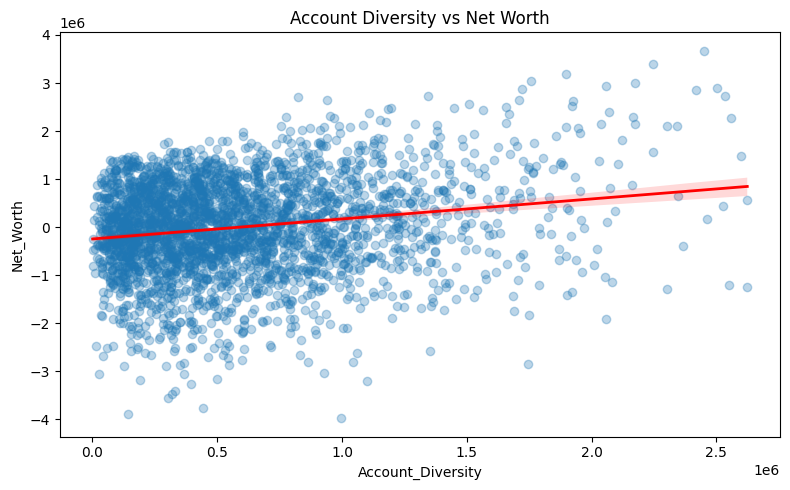

💾Saved


In [39]:
# Visualization

plt.figure(figsize=(8,5))
sns.regplot(
    x='Account_Diversity',
    y='Net_Worth',
    data=df,
    scatter_kws={'alpha':0.3},
    line_kws={'color':'red', 'linewidth':2}
)
plt.title('Account Diversity vs Net Worth')
plt.tight_layout()
plt.savefig('../reports/Results_hypothesis_testing/05_Account_diversity_vs_Net_Worth.png', bbox_inches='tight')
plt.show()
print('💾Saved')

<h4>Hypothesis-6: Does Loyalty Classification affect Total Assets?</h4> 
<h6>Business Qs:</h6> Is the bank's loyalty program effective? 

<b>Null Hypothesis (H₀)</b> Total Assets are equal across all loyalty classifications. </br>
<b>Alternate Hypotheis (H₁)</b> At least one loyalty classification differs.

<h5>Test: Krushal-Wallis</h5>

In [40]:
groups = []

for group in df['Loyalty_Classification'].unique():
    groups.append(
        df[df['Loyalty_Classification']==group]['Total_Assets']
    )
stat, p = kruskal(*groups)

print(f'Statistics: {stat:.3f}')
print(f'P-value: {p} ~ {p:.5f}')

if p < 0.05:
    print("Reject H₀")
else:
    print("Fail to reject H₀")

Statistics: 3.984
P-value: 0.2632123521370278 ~ 0.26321
Fail to reject H₀


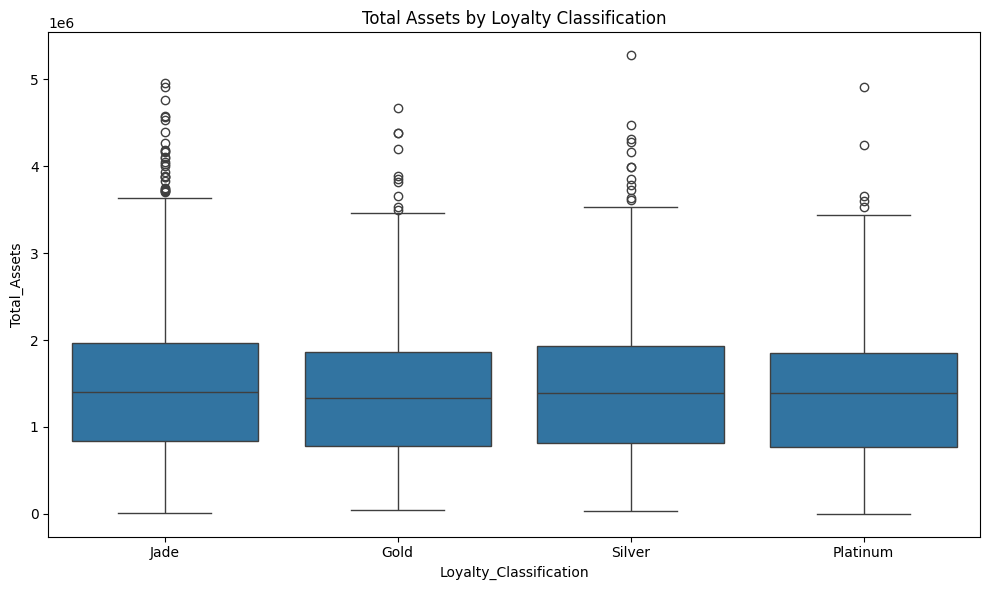

💾Saved


In [41]:
# Visulization
plt.figure(figsize=(10,6))
sns.boxplot(
    x='Loyalty_Classification',
    y='Total_Assets',
    data=df
)
plt.title('Total Assets by Loyalty Classification')
plt.tight_layout()
plt.savefig('../reports/Results_hypothesis_testing/06_risk_weighting_boxplot.png', bbox_inches='tight')
plt.show()
print('💾Saved')

<h4>Hypothesis-7: Does Age Group affect Rosk Weighting?</h4> 
<h6>Business Qs:</h6> Are certain age group financially riskier? 

<b>Null Hypothesis (H₀)</b> Risk Weighting is equal across age groups. </br>
<b>Alternate Hypotheis (H₁)</b> At least one group differs.

<h5>Test: Kruskal-Wallis</h5>

In [42]:
groups = []

for group in df['Age_Group'].unique():
    groups.append(
        df[df['Age_Group']==group]['Risk_Weighting']
    )
stat, p = kruskal(*groups)

print(f"Statistic: {stat:.3f}")
print(f'P-value: {p} ~ {p:.5f}')

if p < 0.05:
    print("Reject H₀")
else:
    print("Fail to Reject H₀")

Statistic: 0.618
P-value: 0.8922436287288488 ~ 0.89224
Fail to Reject H₀


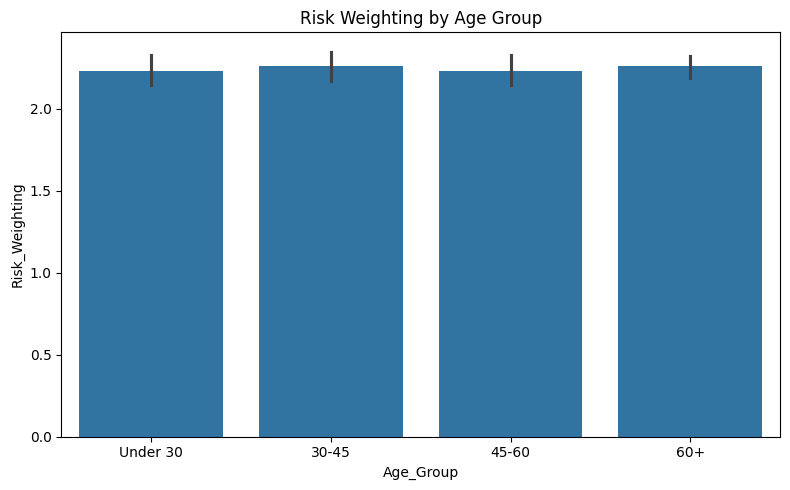

💾Saved


In [43]:
# Visualization

plt.figure(figsize=(8,5))
sns.barplot(
    x='Age_Group',
    y='Risk_Weighting',
    data=df
)
plt.title('Risk Weighting by Age Group')
plt.tight_layout()
plt.savefig('../reports/Results_hypothesis_testing/07_risk_weighting_boxplot.png', bbox_inches='tight')
plt.show()
print('💾Saved')